##### Feladat (Példatár 1.15)

Egy tartó keresztmetszetének terhelése tiszta hajlítás. Az $M_h = 3 ~\mathrm{kNm}$ nagyságú hajlítónyomatéki igénybevétel vektorának irányát és értelmét az alábbi ábra mutatja. A derékszögű háromszög alakú keresztmetszet mérete ismert: $a = 9 ~\mathrm{cm}$.

Feladatok:

a) Határozzuk meg a keresztmetszet mentén a hajlításból adódó normálfeszültség eloszlását!

b) Mekkora n biztonsági tényezővel felel meg hajlításra a tartó ha $\sigma_\mathrm{meg} = 150 ~\mathrm{MPa}$ ?

c) Határozzuk meg a zérustengely $x$-tengellyel bezárt $\beta$ szögét!

<img src="img/01.jpg" alt="Feladat" width=200px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
Mh = 3 # kNm
a = 9 # cm
sigma_meg = 150 # MPa

# Átváltás N, mm, MPa rendszerbe
Mh = Mh * 10**6 # Nmm
a = a * 10 # mm

#### a) Normálfeszültség eloszlás

##### Főirányok helyzete és főmásodrendű nyomatékok

<img src="img/02.jpg" alt="Feladat" width=300px>

In [3]:
I_1 = a**4/24
display(Math(rf'I_1 = {latex(I_1)} ~ \mathrm{{mm^4}}'))

I_2 = a**4/72
display(Math(rf'I_2 = {latex(I_2)} ~ \mathrm{{mm^4}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Hajlítónyomaték felbontása a főirányok mentén

In [4]:
Mh_1 = Mh_2 = Mh*sp.cos(sp.rad(45))
display(Math(rf'M_{{h1}} = M_{{h2}} = {latex(Mh_1.evalf(7))} ~ \mathrm{{Nmm}}'))

<IPython.core.display.Math object>

##### Hajlításból adódó feszültségeloszlások

In [5]:
xh, yh = sp.symbols('x_h, y_h')

sigma_1 = lambda yh: Mh_1 / I_1 * yh
display(Math(rf'\sigma_{{z}}^{{(1)}} = {latex(sigma_1(yh).evalf(5))}'))

sigma_2 = lambda xh: Mh_2 / I_2 * xh
display(Math(rf'\sigma_{{z}}^{{(2)}} = {latex(sigma_2(xh).evalf(5))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Hajlítóigénybevételi függvények

In [6]:
# 1-es tengely körül
sigma_1_max = sigma_1(a/sp.sqrt(2))
sigma_1_min = sigma_1(-a/sp.sqrt(2))

# 2-es tengely körül
sigma_2_max = sigma_2(1/3*a/sp.sqrt(2))
sigma_2_min = sigma_2(-2/3*a/sp.sqrt(2))

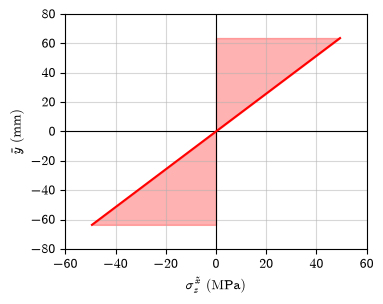

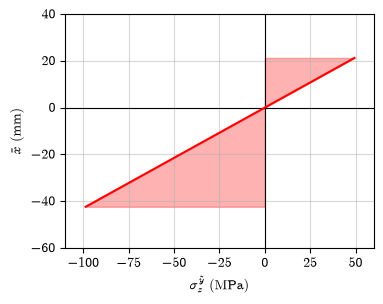

In [7]:
# Ábrrázolás

# 1-es tengely körül
y = np.asarray([a/np.sqrt(2), -a/np.sqrt(2)], dtype=float)
x = np.asarray([sigma_1_max, sigma_1_min], dtype=float)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(x, y, color='red', zorder=5)
plt.fill_betweenx(y, x, 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\sigma_z^{\tilde x} ~ \mathrm{(MPa)}$')
plt.ylabel(r'$\tilde y ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-60, 60)
plt.ylim(-80, 80)
plt.tight_layout()
plt.savefig('1-es_tengely_korul.pdf')
plt.show()

# 2-es tengely körül
y = np.asarray([1/3*a/np.sqrt(2), -2/3*a/np.sqrt(2)], dtype=float)
x = np.asarray([sigma_2_max, sigma_2_min], dtype=float)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(x, y, color='red', zorder=5)
plt.fill_betweenx(y, x, 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\sigma_z^{\tilde y} ~ \mathrm{(MPa)}$')
plt.ylabel(r'$\tilde x ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-110, 60)
plt.ylim(-60, 40)
plt.tight_layout()
plt.savefig('2-es_tengely_korul.pdf')
plt.show()

<img src="img/03.jpg" alt="Feladat" width=350px>

#### b) Biztonsági tényező

In [8]:
sigma_A = sigma_2_min
sigma_B = sigma_1_min + sigma_2_max
sigma_C = sigma_1_max + sigma_2_max

display(Math(rf'\sigma_{{A}} = {latex(round(sigma_A, 3))} ~ \mathrm{{MPa}}'))
display(Math(rf'\sigma_{{B}} = {latex(round(sigma_B, 3))} ~ \mathrm{{MPa}}'))
display(Math(rf'\sigma_{{C}} = {latex(round(sigma_C, 3))} ~ \mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
sigma_max = sp.Max(sigma_A, sigma_B, sigma_C)
display(Math(rf'\sigma_\mathrm{{max}} = {latex(round(sigma_max, 3))} ~ \mathrm{{MPa}}'))

<IPython.core.display.Math object>

In [10]:
n = sigma_meg / sigma_max
display(Math(rf'n = \frac{{\sigma_\mathrm{{meg}}}}{{\sigma_\mathrm{{max}}}} = {latex(round(n, 3))}'))

<IPython.core.display.Math object>

#### c) Zérustengely helye

In [11]:
# Az eredő feszültségeloszlás
sigma_eredo = lambda xh, yh: Mh_1 / I_1 * yh + Mh_2 / I_2 * xh
display(Math(rf'\sigma_{{z}}^{{(1)+(2)}} = {latex(sigma_eredo(xh, yh).evalf(5))}'))

<IPython.core.display.Math object>

In [12]:
# Zérustengely, azon pontok összessége ahol a feszültség zérus
eq = sigma_eredo(xh, yh)

sol = sp.solve(eq, yh)
ysol = sol[0]
display(Math(rf'\tilde y = {latex(ysol)}'))

<IPython.core.display.Math object>

In [13]:
# Szöghelyzet
m = ysol.coeff(xh)
display(Math(rf'\mathrm{{tan}}(\beta) = {latex(m)}'))

beta = sp.Symbol('β')

eq = sp.tan(beta) - m
sol = sp.solve(eq, beta)
beta = sol[0]
beta = sp.deg(beta)

display(Math(rf'\beta = {latex(beta.evalf(5))}^\circ'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<img src="img/04.jpg" alt="Feladat" width=500px>